# In vitro assay analysis


## Directory structure

Data is organized in the following structure:

```
data/
├── metadata.csv
├── images/
│   ├── 1_bf.tif
│   ├── 1_r.tif
│   ├── 2_0.tif
│   └── ...

## metadata.csv example
figure_name,figure_id,channel,seeding_density,virus,cargo,dose_vg/well,image_time_h,receptor,include,notes
1_bf.tif,1,brightfield,0.5e5,AAV9,EGFP,0.5e10,24,EGFRvIII,1,
1_r.tif,1,brightfield,0.5e5,AAV9,EGFP,0.5e10,24,EGFRvIII,1,
```

## Loading data

In [ ]:
import pandas as pd
from cellseg.metadata import load_or_generate_metadata

# Load or generate metadata
df_metadata = load_or_generate_metadata(data_dir='./sample', verbose=True)
print("\nMetadata:")
df_metadata

Looking for metadata file at: ./sample/metadata.csv
Looking for images in: ./sample/images
✓ Found and loaded metadata file (9 rows)

Metadata:


Looking for metadata file at: ./sample/metadata.csv
Looking for images in: ./sample/images
✓ Found and loaded metadata file (9 rows)

Metadata:


,figure_name,figure_id,experiment_id,magnification,channel,seeding_density,virus,cargo,dose_vg/well,image_time_h,receptor,include,notes
0,Image001.tif,1,1,4x,r,50000.0,AAV9,EGFP,5.000000e+09,24,EGFRvIII,0,NaN
1,Image002.tif,2,1,4x,bf,50000.0,AAV9,EGFP,5.000000e+09,24,EGFRvIII,1,NaN
2,Image003.tif,3,1,4x,r,50000.0,AAV9,EGFP,5.000000e+09,24,EGFRvIII,1,NaN
3,Image004.tif,4,2,4x,bf,10000.0,AAV9,EGFP,1.000000e+09,24,EGFRvIII,1,NaN
4,Image005.tif,5,2,4x,r,10000.0,AAV9,EGFP,1.000000e+09,24,EGFRvIII,1,NaN
5,Image006.tif,6,3,4x,bf,50000.0,AAV9,EGFP,5.000000e+09,24,EGFRvIII,1,NaN
6,Image007.tif,7,3,4x,r,50000.0,AAV9,EGFP,5.000000e+09,24,EGFRvIII,1,NaN
7,Image008.tif,8,4,4x,bf,10000.0,AAV9,EGFP,1.000000e+09,24,EGFRvIII,1,NaN
8,Image009.tif,9,4,4x,r,10000.0,AAV9,EGFP,1.000000e+09,24,EGFRvIII,1,NaN


## Example segementaion 

Review the metadata and load images for a specific experiment. Check the workflow of segmentation and quantification.

### Signal Channel Check

Loading BokehJS ...

Experiment 1:
    figure_name channel  experiment_id
1  Image002.tif      bf              1
2  Image003.tif       r              1


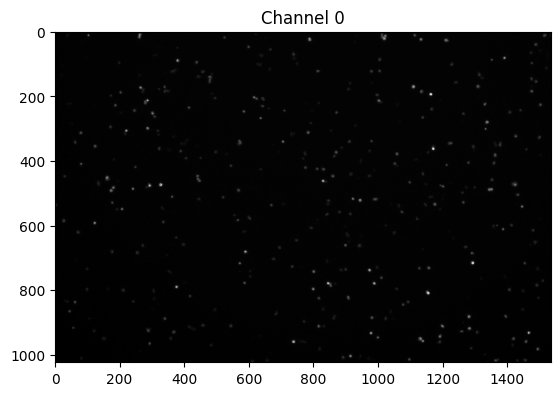

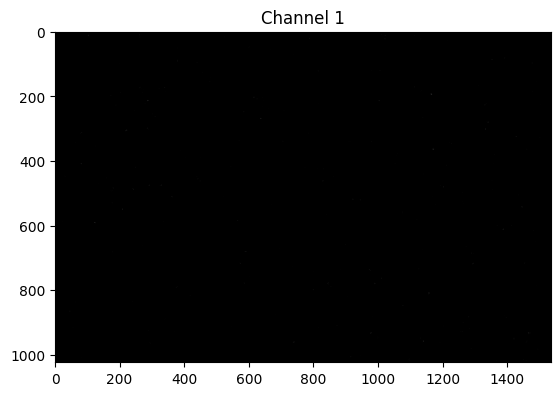

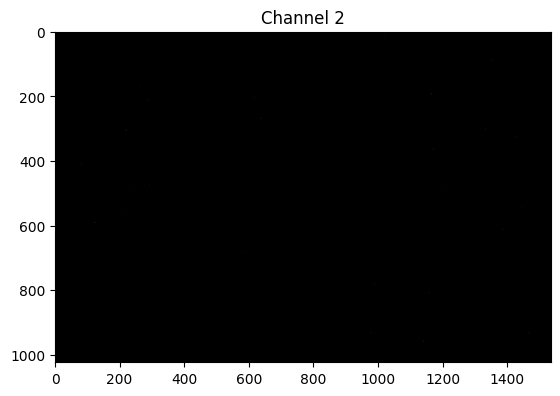

In [28]:
import skimage.io as io
import cellseg.quant
import skimage
import bokeh
bokeh.io.output_notebook()
import matplotlib.pyplot as plt

## Exclude images not marked for inclusion
df_metadata = df_metadata[df_metadata['include'] == 1]

## Load images for a specific experiment
experiment_id = 1

exp_data = df_metadata[df_metadata['experiment_id'] == experiment_id]

print(f"Experiment {experiment_id}:")
print(exp_data[['figure_name', 'channel', 'experiment_id']])

im_sig = exp_data[exp_data['channel'] == 'r']['figure_name'].values[0]
im_sig = f'./sample/images/{im_sig}'
im_bf = exp_data[exp_data['channel'] == 'bf']['figure_name'].values[0]
im_bf = f'./sample/images/{im_bf}'

## Channel Confirmation
im = io.imread(im_sig)

for i in range(im.shape[2]):
    plt.imshow(im[:,:,i], cmap='gray')
    plt.title(f"Channel {i}")
    plt.show()


### Segmentation and Quantification Check

In [38]:
from cellseg import single_experiment_viewer

bf_plot,sig_plot = single_experiment_viewer(im_bf, im_sig)

bokeh.io.show(bf_plot)
bokeh.io.show(sig_plot)

ImportError: cannot import name 'single_experiment_viewer' from 'cellseg' (/Users/longwei/Desktop/janglab/projects/in_vitro_assays/cellseg/__init__.py)